In [1]:
import torch.nn as nn
import torch.optim as optim
import torch
import helper_utils
import pandas as pd
import matplotlib.pyplot as plt
import unittest

In [2]:
file_path = r'C:\Users\SriniAchuthan\Downloads\data_with_features.csv'
data_df = pd.read_csv(file_path)

print(f'Dataset Shape :{data_df}\n')

Dataset Shape :    distance_miles  time_of_day_hours  is_weekend  delivery_time_minutes
0             1.60               8.20           0                   7.22
1            13.09              16.80           1                  32.41
2             6.97               8.02           1                  17.47
3            10.66              16.07           0                  37.17
4            18.24              13.47           0                  38.36
..             ...                ...         ...                    ...
95            7.63              16.53           0                  30.05
96           14.79               8.00           0                  54.38
97           18.05               8.00           0                  64.14
98           17.85              19.36           0                  39.74
99           15.82              19.52           0                  31.65

[100 rows x 4 columns]



In [4]:
rows_to_display = 10
print(data_df.head(rows_to_display))

   distance_miles  time_of_day_hours  is_weekend  delivery_time_minutes
0            1.60               8.20           0                   7.22
1           13.09              16.80           1                  32.41
2            6.97               8.02           1                  17.47
3           10.66              16.07           0                  37.17
4           18.24              13.47           0                  38.36
5            5.74              16.59           0                  29.06
6            8.80              12.25           0                  23.94
7           15.36              11.76           1                  32.40
8            5.35               9.42           0                  17.06
9            2.46              14.44           0                  14.09


In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize



def plot_delivery_data(df):
    """
    Generates a scatter plot of delivery data.

    This function plots delivery time vs. distance, with markers colored by the
    time of day and styled (filled/hollow) based on whether the delivery
    was on a weekend.

    Args:
        df: A DataFrame containing the required columns:
            'distance_miles', 'delivery_time_minutes',
            'time_of_day_hours', and 'is_weekend'.
    """
    # Use a style to get a base grid for the plot
    plt.style.use('seaborn-v0_8-whitegrid')

    # Create the plot figure and axes
    plt.figure(figsize=(12, 7))
    ax = plt.axes()

    # Define colors for the graph's dark theme
    background_color = '#35466A'
    # Color for most text elements
    text_color = 'black'
    grid_color = '#FFFFFF'
    # Shade of grey for legend markers to pop on background
    legend_marker_color = '#CCCCCC'

    # Set the dark background color for the plot area
    ax.set_facecolor(background_color)

    # Separate data for weekend and weekday deliveries
    df_weekend = df[df['is_weekend'] == 1]
    df_weekday = df[df['is_weekend'] == 0]

    # Create a normalizer for consistent color mapping across time of day
    # Choose a colormap for time of day
    cmap = plt.get_cmap('YlOrRd')
    norm = Normalize(vmin=df['time_of_day_hours'].min(), vmax=df['time_of_day_hours'].max())

    # Plot the weekday data (filled circles)
    # Circles are filled and colored by time of day
    scatter_weekday = plt.scatter(
        df_weekday['distance_miles'],
        df_weekday['delivery_time_minutes'],
        s=80,
        # Color based on time of day
        c=df_weekday['time_of_day_hours'],
        cmap=cmap,
        norm=norm,
        alpha=0.9,
        # Label for automatic legend entry
        label='Weekday'
    )

    # Plot the weekend data (hollow circles)
    # Circles are hollow with edges colored by time of day
    scatter_weekend = plt.scatter(
        df_weekend['distance_miles'],
        df_weekend['delivery_time_minutes'],
        s=80,
        # Makes circles hollow
        facecolors='none',
        # Edge colored by time of day
        edgecolors=cmap(norm(df_weekend['time_of_day_hours'])),
        linewidths=1.5,
        alpha=0.9,
        # Label for automatic legend entry
        label='Weekend'
    )

    # Style all non-legend text elements and plot lines
    title_font = {'family': 'sans-serif', 'color': text_color, 'weight': 'bold', 'size': 16}
    label_font = {'family': 'sans-serif', 'color': text_color, 'weight': 'normal', 'size': 12}

    # Main plot titles and axis labels
    ax.set_title('Delivery Time vs. Distance', fontdict=title_font)
    ax.set_xlabel('Distance (miles)', fontdict=label_font)
    ax.set_ylabel('Delivery Time (minutes)', fontdict=label_font)

    # Axis tick parameters and spine (border) colors
    ax.tick_params(axis='x', colors=text_color)
    ax.tick_params(axis='y', colors=text_color)
    for spine in ax.spines.values():
        spine.set_edgecolor(text_color)

    # Grid lines styling
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, color=grid_color, alpha=0.5)

    # Create custom legend handles to ensure generic gray markers
    # Filled gray circle for Weekday in legend
    weekday_handle = Line2D([0], [0], marker='o', color='w', label='Weekday',
                            markerfacecolor=legend_marker_color, markersize=8,
                            markeredgecolor=legend_marker_color, markeredgewidth=1.5,
                            # Prevents a line from being drawn through the marker
                            linestyle='None')

    # Hollow gray circle for Weekend in legend
    weekend_handle = Line2D([0], [0], marker='o', color='w', label='Weekend',
                            markerfacecolor='none', markersize=8,
                            markeredgecolor=legend_marker_color, markeredgewidth=1.5,
                            # Prevents a line from being drawn through the marker
                            linestyle='None')

    # Add and Style Legend using the custom handles and text colors
    # Explicitly provide handles and labels to override default scatter legend entries
    legend = ax.legend(handles=[weekday_handle, weekend_handle],
                       labels=['Weekday', 'Weekend'],
                       title='Day Type')

    # Set the color for all legend text items (labels) to white
    plt.setp(legend.get_texts(), color='white', fontsize=12)
    # Set the color for the legend title to white
    plt.setp(legend.get_title(), color='white', fontsize=13, weight='bold')

    # Add and style the colorbar for Time of Day
    # The colorbar uses the 'scatter_weekday' plot for its color mapping source
    cbar = plt.colorbar(scatter_weekday, ax=ax)
    cbar.set_label('Time of Day (Hour)', fontdict=label_font)
    # Colorbar tick labels also in black
    cbar.ax.tick_params(colors=text_color)

    # Display the plot
    plt.show()


    
def plot_rush_hour(data_df, features):
    """
    Generates a scatter plot of delivery data, grouped by rush hour.
    Features larger markers and custom legend text for better visibility on a dark background.

    Args:
        data_df: DataFrame with original data ('distance_miles', 'delivery_time_minutes').
        features: The prepared features tensor with the 'is_rush_hour' column.
    """
    # Set the plotting style to include a grid
    plt.style.use('seaborn-v0_8-whitegrid')

    # Create the figure and axes for the plot
    plt.figure(figsize=(12, 7))
    ax = plt.axes()

    # Define colors for the plot's visual theme
    # Background color of the plot area
    background_color = '#35466A'
    # Color for "Rush Hour" data points (orange)
    rush_hour_color = '#E64C29'
    # Color for "Not Rush Hour" data points (light grey)
    default_color = '#F0F0E0'
    # General color for axis labels, tick labels, and main titles
    text_color = 'black'
    # Color for grid lines
    grid_color = '#FFFFFF'

    # Apply the defined background color to the plot axes
    ax.set_facecolor(background_color)

    # Prepare the 'is_rush_hour' boolean array from features for data separation
    is_rush_hour = features[:, 3].numpy().astype(bool)

    # Plot data points for "Rush Hour" deliveries
    # Data points are large, filled, and colored with 'rush_hour_color'.
    # Their edge color now matches their fill color for consistency.
    scatter_rush_hour = plt.scatter(
        data_df['distance_miles'][is_rush_hour],
        data_df['delivery_time_minutes'][is_rush_hour],
        # Marker size for visibility
        s=90,
        c=rush_hour_color,
        # Opacity for slight transparency
        alpha=0.9,
        # Edge color matches fill color
        edgecolor=rush_hour_color,
        # Line width for marker edges
        linewidth=0.5,
        # Label for legend entry
        label='Rush Hour'
    )

    # Plot data points for "Not Rush Hour" deliveries
    # Data points are large, filled, and colored with 'default_color'.
    scatter_not_rush_hour = plt.scatter(
        data_df['distance_miles'][~is_rush_hour],
        data_df['delivery_time_minutes'][~is_rush_hour],
        # Marker size for visibility
        s=90,
        c=default_color,
        # Opacity for slight transparency
        alpha=0.7,
        # Label for legend entry
        label='Not Rush Hour'
    )

    # Define font properties for plot titles and labels
    title_font = {'family': 'sans-serif', 'color': text_color, 'weight': 'bold', 'size': 16}
    label_font = {'family': 'sans-serif', 'color': text_color, 'weight': 'normal', 'size': 12}

    # Set the main plot title and axis labels
    ax.set_title('Delivery Time vs. Distance (Grouped by Delivery Time Slots)', fontdict=title_font)
    ax.set_xlabel('Distance (miles)', fontdict=label_font)
    ax.set_ylabel('Delivery Time (minutes)', fontdict=label_font)

    # Style axis ticks and the plot's outer border (spines)
    ax.tick_params(axis='x', colors=text_color)
    ax.tick_params(axis='y', colors=text_color)
    for spine in ax.spines.values():
        spine.set_edgecolor(text_color)

    # Add and style grid lines for better readability
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, color=grid_color, alpha=0.5)

    # Custom Legend Configuration
    # Create Line2D objects to serve as custom legend handles.
    # These handles display the desired marker style and color without a connecting line.

    # Handle for "Rush Hour" (filled orange circle)
    rush_hour_handle = Line2D([0], [0], marker='o', color='w', label='Rush Hour',
                              markerfacecolor=rush_hour_color, markersize=10,
                              # Edge color matches fill color
                              markeredgecolor=rush_hour_color,
                              markeredgewidth=0.5, linestyle='None')

    # Handle for "Not Rush Hour" (filled light grey circle)
    not_rush_hour_handle = Line2D([0], [0], marker='o', color='w', label='Not Rush Hour',
                                  markerfacecolor=default_color, markersize=10,
                                  markeredgecolor='none', linestyle='None')

    # Create the legend using the custom handles and labels, with a specific title
    legend = ax.legend(handles=[rush_hour_handle, not_rush_hour_handle],
                       labels=['Rush Hour', 'Not Rush Hour'],
                       title='Delivery Time Slot')

    # Set the background and edge color for the legend frame
    legend.get_frame().set_facecolor('#4A6C8C')
    legend.get_frame().set_edgecolor('none')

    # Style the legend title: set color to white and adjust font size/weight/alignment
    plt.setp(legend.get_title(), color='white', fontsize=15, weight='bold',
             # Horizontal alignment for the title
             ha='left')

    # Style the legend labels: set their color to match their data points and adjust font size
    text_labels = legend.get_texts()
    text_labels[0].set_color(rush_hour_color)
    text_labels[0].set_fontsize(14)
    text_labels[1].set_color(default_color)
    text_labels[1].set_fontsize(14)

    # Display the plot
    plt.show()


    
def plot_final_data(features, targets):
    """
    Generates a scatter plot of the final, processed data,
    ensuring all four possible categories appear in the legend.

    Args:
        features: The prepared 4D features tensor.
        targets: The prepared targets tensor.
    """
    # Set the plotting style to include a grid
    plt.style.use('seaborn-v0_8-whitegrid')

    # Create the figure and axes for the plot
    plt.figure(figsize=(12, 7))
    ax = plt.axes()

    # Define colors from the theme
    background_color = '#35466A'
    # Color for rush hour data points
    rush_hour_color = '#E64C29'
    # Color for non-rush hour/default data points
    default_color = '#F0F0E0'
    # General color for most graph text
    text_color = 'black'
    # Color for grid lines
    grid_color = '#FFFFFF'

    # Apply the defined background color to the plot axes
    ax.set_facecolor(background_color)

    # Prepare data for plotting
    normalized_distance = features[:, 0].numpy()
    delivery_time = targets.numpy()
    is_weekend = features[:, 2].numpy().astype(bool)
    is_rush_hour = features[:, 3].numpy().astype(bool)

    # Create boolean masks for each of the four delivery categories
    weekday_rush = is_rush_hour & ~is_weekend
    weekday_non_rush = ~is_rush_hour & ~is_weekend
    weekend_rush = is_rush_hour & is_weekend
    weekend_non_rush = ~is_rush_hour & is_weekend

    # Plot the four data categories
    # Plotting order here affects layer visibility for overlapping points.

    # 1. Weekday (Rush Hour): Filled orange circles
    plt.scatter(
        normalized_distance[weekday_rush],
        delivery_time[weekday_rush],
        s=90, c=rush_hour_color, alpha=0.9,
        label='Weekday (Rush Hour)'
    )

    # 2. Weekday (Not Rush Hour): Filled white/light gray circles
    plt.scatter(
        normalized_distance[weekday_non_rush],
        delivery_time[weekday_non_rush],
        s=90, c=default_color, alpha=0.7,
        label='Weekday (Not Rush Hour)'
    )

    # 3. Weekend (Rush Hour): Hollow orange circles
    plt.scatter(
        normalized_distance[weekend_rush],
        delivery_time[weekend_rush],
        s=90, facecolors='none', edgecolors=rush_hour_color,
        linewidths=1.5, alpha=0.9,
        label='Weekend (Rush Hour)'
    )

    # 4. Weekend (Not Rush Hour): Hollow white/light gray circles
    plt.scatter(
        normalized_distance[weekend_non_rush],
        delivery_time[weekend_non_rush],
        s=90, facecolors='none', edgecolors=default_color,
        linewidths=1.5, alpha=0.7,
        label='Weekend (Not Rush Hour)'
    )

    # Style plot titles and axis labels
    title_font = {'family': 'sans-serif', 'color': text_color, 'weight': 'bold', 'size': 16}
    label_font = {'family': 'sans-serif', 'color': text_color, 'weight': 'normal', 'size': 12}

    ax.set_title('Final Processed Data for Training', fontdict=title_font)
    ax.set_xlabel('Normalized Distance (miles)', fontdict=label_font)
    ax.set_ylabel('Delivery Time (minutes)', fontdict=label_font)

    # Style axis ticks and plot border (spines)
    ax.tick_params(axis='x', colors=text_color)
    ax.tick_params(axis='y', colors=text_color)
    for spine in ax.spines.values():
        spine.set_edgecolor(text_color)

    # Add and style grid lines
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, color=grid_color, alpha=0.5)

    # Custom Legend Configuration
    # Create Line2D objects to serve as custom legend handles.
    # These handles will display the specified marker style and color without a connecting line.

    # Handle for Weekday (Rush Hour) - Filled Orange circle
    weekday_rush_handle = Line2D([0], [0], marker='o', color='w', markerfacecolor=rush_hour_color,
                                 markersize=10, linestyle='None',
                                 markeredgecolor=rush_hour_color, markeredgewidth=0.5)

    # Handle for Weekday (Not Rush Hour) - Filled White circle
    weekday_non_rush_handle = Line2D([0], [0], marker='o', color='w', markerfacecolor=default_color,
                                     markersize=10, linestyle='None')

    # Handle for Weekend (Rush Hour) - Hollow Orange circle
    weekend_rush_handle = Line2D([0], [0], marker='o', color='w', markerfacecolor='none',
                                 markeredgecolor=rush_hour_color, markeredgewidth=1.5,
                                 markersize=10, linestyle='None')

    # Handle for Weekend (Not Rush Hour) - Hollow White circle
    weekend_non_rush_handle = Line2D([0], [0], marker='o', color='w', markerfacecolor='none',
                                     markeredgecolor=default_color, markeredgewidth=1.5,
                                     markersize=10, linestyle='None')

    # Create the legend using the custom handles in the specified order and set its title
    legend = ax.legend(
        handles=[
            weekday_rush_handle,
            weekday_non_rush_handle,
            weekend_rush_handle,
            weekend_non_rush_handle
        ],
        labels=[
            'Weekday (Rush Hour)',
            'Weekday (Not Rush Hour)',
            'Weekend (Rush Hour)',
            'Weekend (Not Rush Hour)'
        ],
        title='Delivery Type'
    )

    # Style the legend frame's background and edge
    legend.get_frame().set_facecolor('#4A6C8C')
    legend.get_frame().set_edgecolor('none')

    # Style the legend title: set color to white and adjust font size/weight
    plt.setp(legend.get_title(), color='white', fontsize=15, weight='bold')

    # Style the legend labels: set their color to match respective circle colors and adjust font size
    text_labels = legend.get_texts()
    for label_text in text_labels:
        label_text.set_fontsize(14)

    text_labels[0].set_color(rush_hour_color)
    text_labels[1].set_color(default_color)
    text_labels[2].set_color(rush_hour_color)
    text_labels[3].set_color(default_color)

    # Display the plot
    plt.show()


    
def plot_model_predictions(predicted_outputs, actual_targets):
    """
    Creates a themed scatter plot to compare actual vs. predicted values.

    Args:
        predicted_outputs: The tensor of predictions from the model.
        actual_targets: The tensor of actual target values.
    """
    # Define colors from the established theme
    background_color = '#35466A'
    text_color = 'black'
    grid_color = '#FFFFFF'
    model_predictions_color = '#F0F0E0'
    perfect_prediction_line_color = '#E64C29'

    # Set the plotting style
    plt.style.use('seaborn-v0_8-whitegrid')

    # Detach tensors and convert to NumPy arrays for plotting
    predicted_values = predicted_outputs.detach().numpy()
    actual_values = actual_targets.detach().numpy()

    # Create the plot figure and axes
    plt.figure(figsize=(12, 7))
    ax = plt.axes()
    ax.set_facecolor(background_color)

    # Create the scatter plot
    ax.scatter(
        actual_values,
        predicted_values,
        s=90,
        c=model_predictions_color,
        alpha=0.7,
        edgecolor=model_predictions_color,
        linewidth=0.5,
        label='Model Predictions'
    )

    # Add the "perfect prediction" line
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(
        lims, lims,
        linestyle='-',
        color=perfect_prediction_line_color,
        alpha=0.75,
        zorder=0,
        label='Perfect Prediction'
    )

    # Define font properties
    title_font = {'family': 'sans-serif', 'color': text_color, 'weight': 'bold', 'size': 16}
    label_font = {'family': 'sans-serif', 'color': text_color, 'weight': 'normal', 'size': 12}

    # Set titles and labels
    ax.set_title('Actual vs. Predicted Delivery Times', fontdict=title_font)
    ax.set_xlabel('Actual Delivery Time (minutes)', fontdict=label_font)
    ax.set_ylabel('Predicted Delivery Time (minutes)', fontdict=label_font)

    # Style ticks and spines
    ax.tick_params(axis='x', colors=text_color)
    ax.tick_params(axis='y', colors=text_color)
    for spine in ax.spines.values():
        spine.set_edgecolor(text_color)

    # Style grid
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, color=grid_color, alpha=0.5)

    # Custom Legend Configuration
    model_pred_handle = Line2D([0], [0], marker='o', color='w', markerfacecolor=model_predictions_color,
                               markersize=10, linestyle='None')
    perfect_pred_handle = Line2D([0], [0], color=perfect_prediction_line_color, linewidth=2,
                                 label='Perfect Prediction')

    legend = ax.legend(
        handles=[model_pred_handle, perfect_pred_handle],
        labels=['Model Predictions', 'Perfect Prediction'],
        title='Prediction Insights'
    )

    # Style the legend
    legend.get_frame().set_facecolor('#4A6C8C')
    legend.get_frame().set_edgecolor('none')
    plt.setp(legend.get_title(), color='white', fontsize=15, weight='bold', ha='left')
    text_labels = legend.get_texts()
    text_labels[0].set_color(model_predictions_color)
    text_labels[0].set_fontsize(14)
    text_labels[1].set_color(perfect_prediction_line_color)
    text_labels[1].set_fontsize(14)

    # Display the plot
    plt.show()


    
def prediction(model, data_df, raw_inputs, rush_hour_feature_func):
    """
    Takes raw inputs as a tensor, validates them, prepares them for the model, 
    predicts the delivery time, and displays the results in a formatted table.

    Args:
        model: The trained PyTorch model.
        data_df: The original training DataFrame for calculating stats.
        raw_inputs: A tensor containing the raw input values
                    in the format [distance, time_of_day, is_weekend].
        rush_hour_feature_func: The function to engineer the rush hour feature.

    Returns:
        None: This function prints output directly and returns None on success.
              On validation failure, it prints an error and returns early.
    """
    # 1. Validate User Inputs
    # Extract scalar values from the input tensor for validation checks.
    distance_value = raw_inputs[0, 0].item()
    time_value = raw_inputs[0, 1].item()
    weekend_value = raw_inputs[0, 2].item()

    # Check for a valid distance.
    if distance_value <= 0:
        print(f"\033[91mError: Invalid distance value - The value must be greater than 0 and no more than 20 miles.")
        return

    # Check for a valid time.
    if time_value <= 0 or time_value > 24:
        print(f"\033[91mError: Invalid time value - The value must be greater than 0 and no more than 24.0.")
        return

    # Check if the weekend flag is a valid boolean (0 or 1).
    if weekend_value not in [0.0, 1.0]:
        print(f"\033[91mError: Invalid weekend value - Please use 1 (True) for a weekend or 0 (False) for a weekday.")
        return

    # Check if the distance exceeds the service area.
    if distance_value > 20:
        print(f"\033[91mDelivery Area Exceeded: The requested distance of {distance_value:.1f} miles exceeds the 20-mile limit.")
        return

    # Check if the time is within operating hours.
    if time_value <= 8 or time_value > 20:
        print(f"\033[91mOutside Operating Hours: Deliveries are only processed between 8:00 and 20:00.")
        return

    # 2. Recalculate Normalization Stats
    # In a real application, these stats would be saved after training and loaded here.
    dist_mean = data_df['distance_miles'].mean()
    dist_std = data_df['distance_miles'].std()
    hours_mean = data_df['time_of_day_hours'].mean()
    hours_std = data_df['time_of_day_hours'].std()

    # 3. Prepare Input Tensors for the Model
    # Slice the input tensor to get individual feature tensors.
    distance_tensor = raw_inputs[:, 0]
    hours_tensor = raw_inputs[:, 1]
    weekend_tensor = raw_inputs[:, 2]

    # Engineer the rush hour feature using the provided function.
    is_rush_hour_tensor = rush_hour_feature_func(hours_tensor, weekend_tensor)

    # Normalize the continuous features using the stats from the training data.
    normalized_distance = (distance_tensor - dist_mean) / dist_std
    normalized_hours = (hours_tensor - hours_mean) / hours_std

    # Combine all engineered and normalized features into a final tensor for the model.
    new_features = torch.cat([
        normalized_distance.unsqueeze(0),
        normalized_hours.unsqueeze(0),
        weekend_tensor.unsqueeze(0),
        is_rush_hour_tensor.unsqueeze(0)
    ], dim=1)

    # 4. Make the Prediction
    # Use torch.no_grad() for inference as we are not training the model.
    with torch.no_grad():
        # Set the model to evaluation mode.
        model.eval()
        predicted_time_tensor = model(new_features)

    # 5. Format and Display the Results
    # Extract the final prediction and format all values for display.
    predicted_time = predicted_time_tensor.item()
    time_of_week = "Weekend" if weekend_value else "Weekday"
    is_rush_hour_text = "Yes" if is_rush_hour_tensor.item() == 1.0 else "No"
    hour = int(time_value)
    minutes = int((time_value % 1) * 60)
    formatted_time = f"{hour:02d}:{minutes:02d}"

    # Define the table structure for clean output.
    header = "+{:-<42}+{:-<23}+".format('', '')
    title_line = "|{:^66}|".format(" Model Prediction ")
    line1 = f"| {'Time of the Week':<40} | {time_of_week:<21} |"
    line2 = f"| {'Distance':<40} | {f'{distance_value:.1f} miles':<21} |"
    line3 = f"| {'Time':<40} | {formatted_time:<21} |"
    line4 = f"| {'Is this considered a rush hour period?':<40} | {is_rush_hour_text:<21} |"
    final_result = f"| {'Estimated Delivery Time':<40} | {f'{predicted_time:.2f} minutes':<21} |"
    
    # Print the formatted table.
    print(header)
    print(title_line)
    print(header)
    print(line1)
    print(line2)
    print(line3)
    print(line4)
    print(header)
    print(final_result)
    print(header)

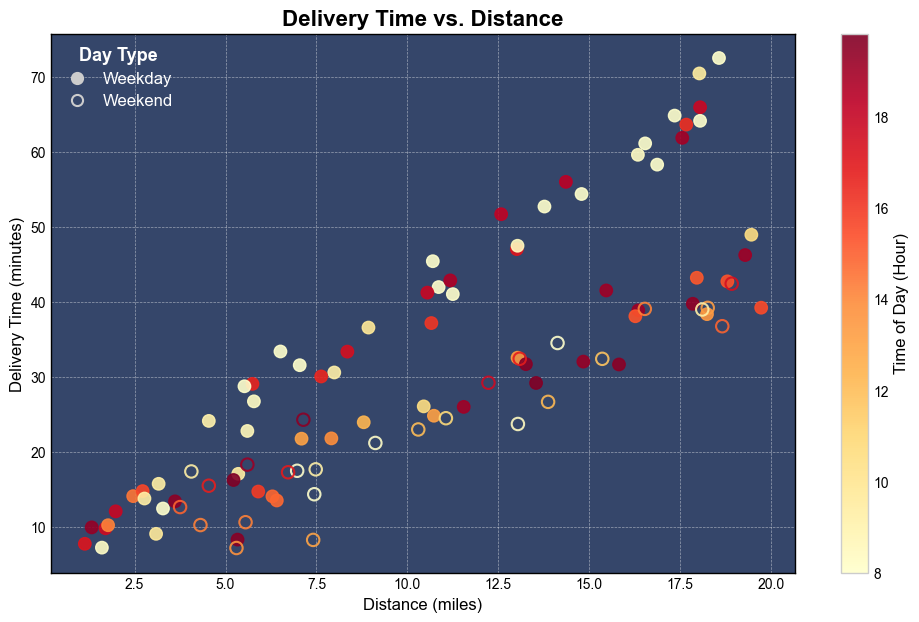

In [10]:
plot_delivery_data(data_df)

In [11]:
sample_tensor = torch.tensor([
    # distance, time_of_day, is_weekend, delivery_time
    [1.60,      8.20,        0,          7.22],   # row 1
    [13.09,     16.80,       1,          32.41],  # row 2       
    [6.97,      8.02,        1,          17.47],  # row 3
    [10.66,     16.07,       0,          37.17],  # row 4
    [18.24,     13.47,       0,          38.36]   # row 5
], dtype=torch.float32)

In [12]:
sample_hours = sample_tensor[:, 1]
sample_weekends = sample_tensor[:, 2]

print("--- Sliced Tensors ---")
print(f"Sample Hours:    {sample_hours}")
print(f"Sample Weekends: {sample_weekends}\n")

--- Sliced Tensors ---
Sample Hours:    tensor([ 8.2000, 16.8000,  8.0200, 16.0700, 13.4700])
Sample Weekends: tensor([0., 1., 1., 0., 0.])



In [19]:
#Exercise 1 - rush_hour_feature

def rush_hour_feature(hours_tensor, weekends_tensor):
    """
    Engineers a new binary feature indicating if a delivery is in a weekday rush hour.

    Args:
        hours_tensor (torch.Tensor): A tensor of delivery times of day.
        weekends_tensor (torch.Tensor): A tensor indicating if a delivery is on a weekend.

    Returns:
        torch.Tensor: A tensor of 0s and 1s indicating weekday rush hour.
    """

    is_morning_rush = (hours_tensor >= 8) & (hours_tensor < 10)
    is_evening_rush = (hours_tensor < 19) & (hours_tensor >= 16)
    is_weekday = (weekends_tensor == 0)

    ### START CODE HERE ###


    
        
    
    # Define rush hour and weekday conditions
    is_rush_hour_mask = is_weekday & (is_morning_rush | is_evening_rush)

    ### END CODE HERE ###

    # Convert the boolean mask to a float tensor to use as a numerical feature
    return is_rush_hour_mask.float()

In [20]:
rush_hour_for_sample = rush_hour_feature(sample_hours, sample_weekends)

print(f"Sample Hours:     {sample_hours.numpy()}")
print(f"Sample Weekends:  {sample_weekends.numpy()}")
print(f"Is Rush Hour?:    {rush_hour_for_sample.numpy()}")

Sample Hours:     [ 8.2  16.8   8.02 16.07 13.47]
Sample Weekends:  [0. 1. 1. 0. 0.]
Is Rush Hour?:    [1. 0. 0. 1. 0.]


In [31]:
print(sample_hours.shape)
print(sample_weekends.shape)

torch.Size([5])
torch.Size([5])


KeyError: 'distance_miles'

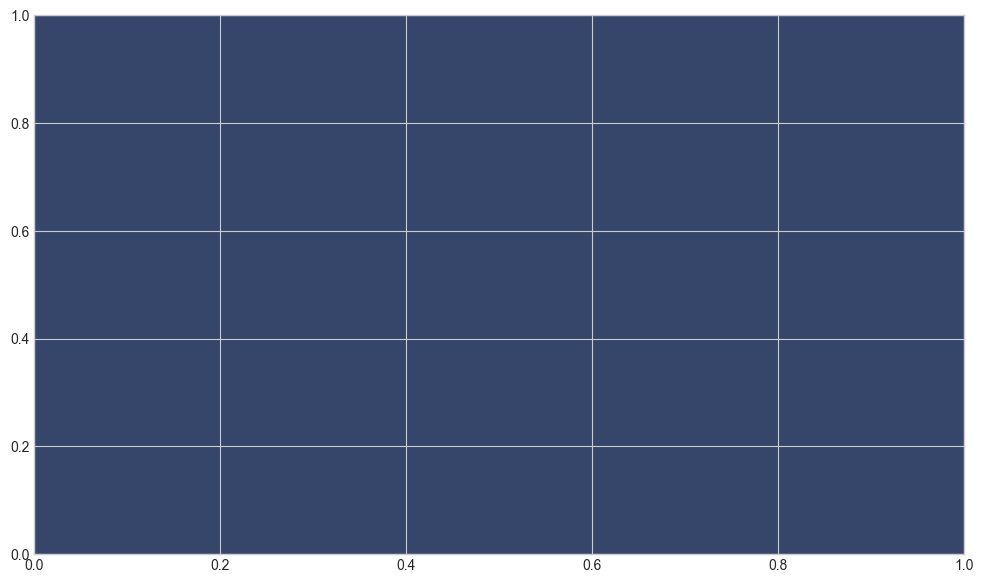

In [34]:
# Check if these exist
rush_hour_for_sample = pd.DataFrame({
      'time_of_day_hours': sample_hours.numpy(),
      'is_weekend':        sample_weekends.numpy(),
      'is_rush_hour':      rush_hour_feature(sample_hours, sample_weekends).numpy().astype(int)
})

plot_delivery_data(rush_hour_for_sample)

In [44]:
def prepare_data(df):
    """
    Converts a pandas DataFrame into prepared PyTorch tensors for modeling.

    Args:
        df (pd.DataFrame): A pandas DataFrame containing the raw delivery data.

    Returns:
        prepared_features (torch.Tensor): The final 2D feature tensor for the model.
        prepared_targets (torch.Tensor): The final 2D target tensor.
        results_dict (dict): A dictionary of intermediate tensors for testing purposes.
    """

    # Extract the data from the DataFrame as a NumPy array
    # (There's no direct torch.from_dataframe(), so we use .values to get a NumPy array first)
    all_values = df.values

    ### START CODE HERE ###

    # Convert all the values from the DataFrame into a single PyTorch tensor
    full_tensor = torch.tensor(all_values , dtype = torch.float32)
    

    # Use tensor slicing to separate out each raw column
    raw_distances = full_tensor[:,0]
    raw_hours = full_tensor[:,1]
    raw_weekends = full_tensor[:,2]
    raw_targets = full_tensor[:,3]

    # Call your rush_hour_feature() function to engineer the new feature
    is_rush_hour_feature = rush_hour_feature(raw_hours,raw_weekends)

    # Use the .unsqueeze(1) method to reshape the four 1D feature tensors into 2D column vectors
    distances_col = raw_distances.unsqueeze(1)
    hours_col = raw_hours.unsqueeze(1)
    weekends_col = raw_weekends.unsqueeze(1)
    rush_hour_col = is_rush_hour_feature.unsqueeze(1)


    ### END CODE HERE ###

    # Normalize the continuous feature columns (distance and time)
    dist_mean, dist_std = distances_col.mean(), distances_col.std()
    hours_mean, hours_std = hours_col.mean(), hours_col.std()
 
    distances_norm = (distances_col - dist_mean) / dist_std
    hours_norm = (hours_col - hours_mean) / hours_std

    # Combine all prepared 2D features into a single tensor
    prepared_features = torch.cat([
        distances_norm,
        hours_norm,
        weekends_col,
        rush_hour_col
    ], dim=1) # dim=1 concatenates them column-wise, stacking features side by side

    # Prepare targets by ensuring they are the correct shape
    prepared_targets = raw_targets.unsqueeze(1)
    
    # Dictionary for Testing Purposes
    results_dict = {
        'full_tensor': full_tensor,
        'raw_distances': raw_distances,
        'raw_hours': raw_hours,
        'raw_weekends': raw_weekends,
        'raw_targets': raw_targets,
        'distances_col': distances_col,
        'hours_col': hours_col,
        'weekends_col': weekends_col,
        'rush_hour_col': rush_hour_col
    }
    

    return prepared_features, prepared_targets, results_dict



In [45]:
# Create a small test DataFrame with the first 5 entries
test_df = data_df.head(5).copy()

# Print the "Before" state as a raw tensor
raw_test_tensor = torch.tensor(test_df.values, dtype=torch.float32)
print("--- Raw Tensor (Before Preparation) ---\n")
print(f"Shape: {raw_test_tensor.shape}")
print("Values:\n", raw_test_tensor)
print("\n" + "="*50 + "\n")

# Run the function to get the prepared "after" tensors
test_features, test_targets, _ = prepare_data(test_df)

# Print the "After" state
print("--- Prepared Tensors (After Preparation) ---")
print("\n--- Prepared Features ---\n")
print(f"Shape: {test_features.shape}")
print("Values:\n", test_features)

print("\n--- Prepared Targets ---")
print(f"Shape: {test_targets.shape}")
print("Values:\n", test_targets)

--- Raw Tensor (Before Preparation) ---

Shape: torch.Size([5, 4])
Values:
 tensor([[ 1.6000,  8.2000,  0.0000,  7.2200],
        [13.0900, 16.8000,  1.0000, 32.4100],
        [ 6.9700,  8.0200,  1.0000, 17.4700],
        [10.6600, 16.0700,  0.0000, 37.1700],
        [18.2400, 13.4700,  0.0000, 38.3600]])


--- Prepared Tensors (After Preparation) ---

--- Prepared Features ---

Shape: torch.Size([5, 4])
Values:
 tensor([[-1.3562, -1.0254,  0.0000,  1.0000],
        [ 0.4745,  1.0197,  1.0000,  0.0000],
        [-0.5006, -1.0682,  1.0000,  0.0000],
        [ 0.0873,  0.8461,  0.0000,  1.0000],
        [ 1.2951,  0.2278,  0.0000,  0.0000]])

--- Prepared Targets ---
Shape: torch.Size([5, 1])
Values:
 tensor([[ 7.2200],
        [32.4100],
        [17.4700],
        [37.1700],
        [38.3600]])


In [46]:
prepare_data(data_df)

(tensor([[-1.5906e+00, -1.2407e+00,  0.0000e+00,  1.0000e+00],
         [ 4.7244e-01,  7.8214e-01,  1.0000e+00,  0.0000e+00],
         [-6.2642e-01, -1.2830e+00,  1.0000e+00,  0.0000e+00],
         [ 3.6126e-02,  6.1044e-01,  0.0000e+00,  1.0000e+00],
         [ 1.3971e+00, -1.1054e-03,  0.0000e+00,  0.0000e+00],
         [-8.4727e-01,  7.3274e-01,  0.0000e+00,  1.0000e+00],
         [-2.9784e-01, -2.8806e-01,  0.0000e+00,  0.0000e+00],
         [ 8.8002e-01, -4.0331e-01,  1.0000e+00,  0.0000e+00],
         [-9.1729e-01, -9.5370e-01,  0.0000e+00,  1.0000e+00],
         [-1.4362e+00,  2.2705e-01,  0.0000e+00,  0.0000e+00],
         [-7.0901e-01, -1.2877e+00,  0.0000e+00,  1.0000e+00],
         [-1.1489e+00, -9.7487e-01,  1.0000e+00,  0.0000e+00],
         [ 1.4725e+00,  3.2583e-01,  1.0000e+00,  0.0000e+00],
         [ 1.0578e+00,  1.3208e+00,  0.0000e+00,  0.0000e+00],
         [ 4.6166e-01, -1.2866e-02,  0.0000e+00,  0.0000e+00],
         [ 1.2750e+00,  1.2808e+00,  0.0000e+00,  1.000

In [47]:
features, targets, _ = prepare_data(data_df)